In [16]:
import warnings
warnings.filterwarnings("ignore")

import astropy.io.fits as fits
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import os
import pandas as pd
import glob

from create_figs import create_m0_map, mark_sources_2, plot_vector

INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  1.652e-01 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  1.066e-01 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  9.976e-02 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  1.863e-01 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  8.601e-02 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  6.231e-02 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  2.154e-01 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  4.928e-02 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  8.365e-02 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  2.5

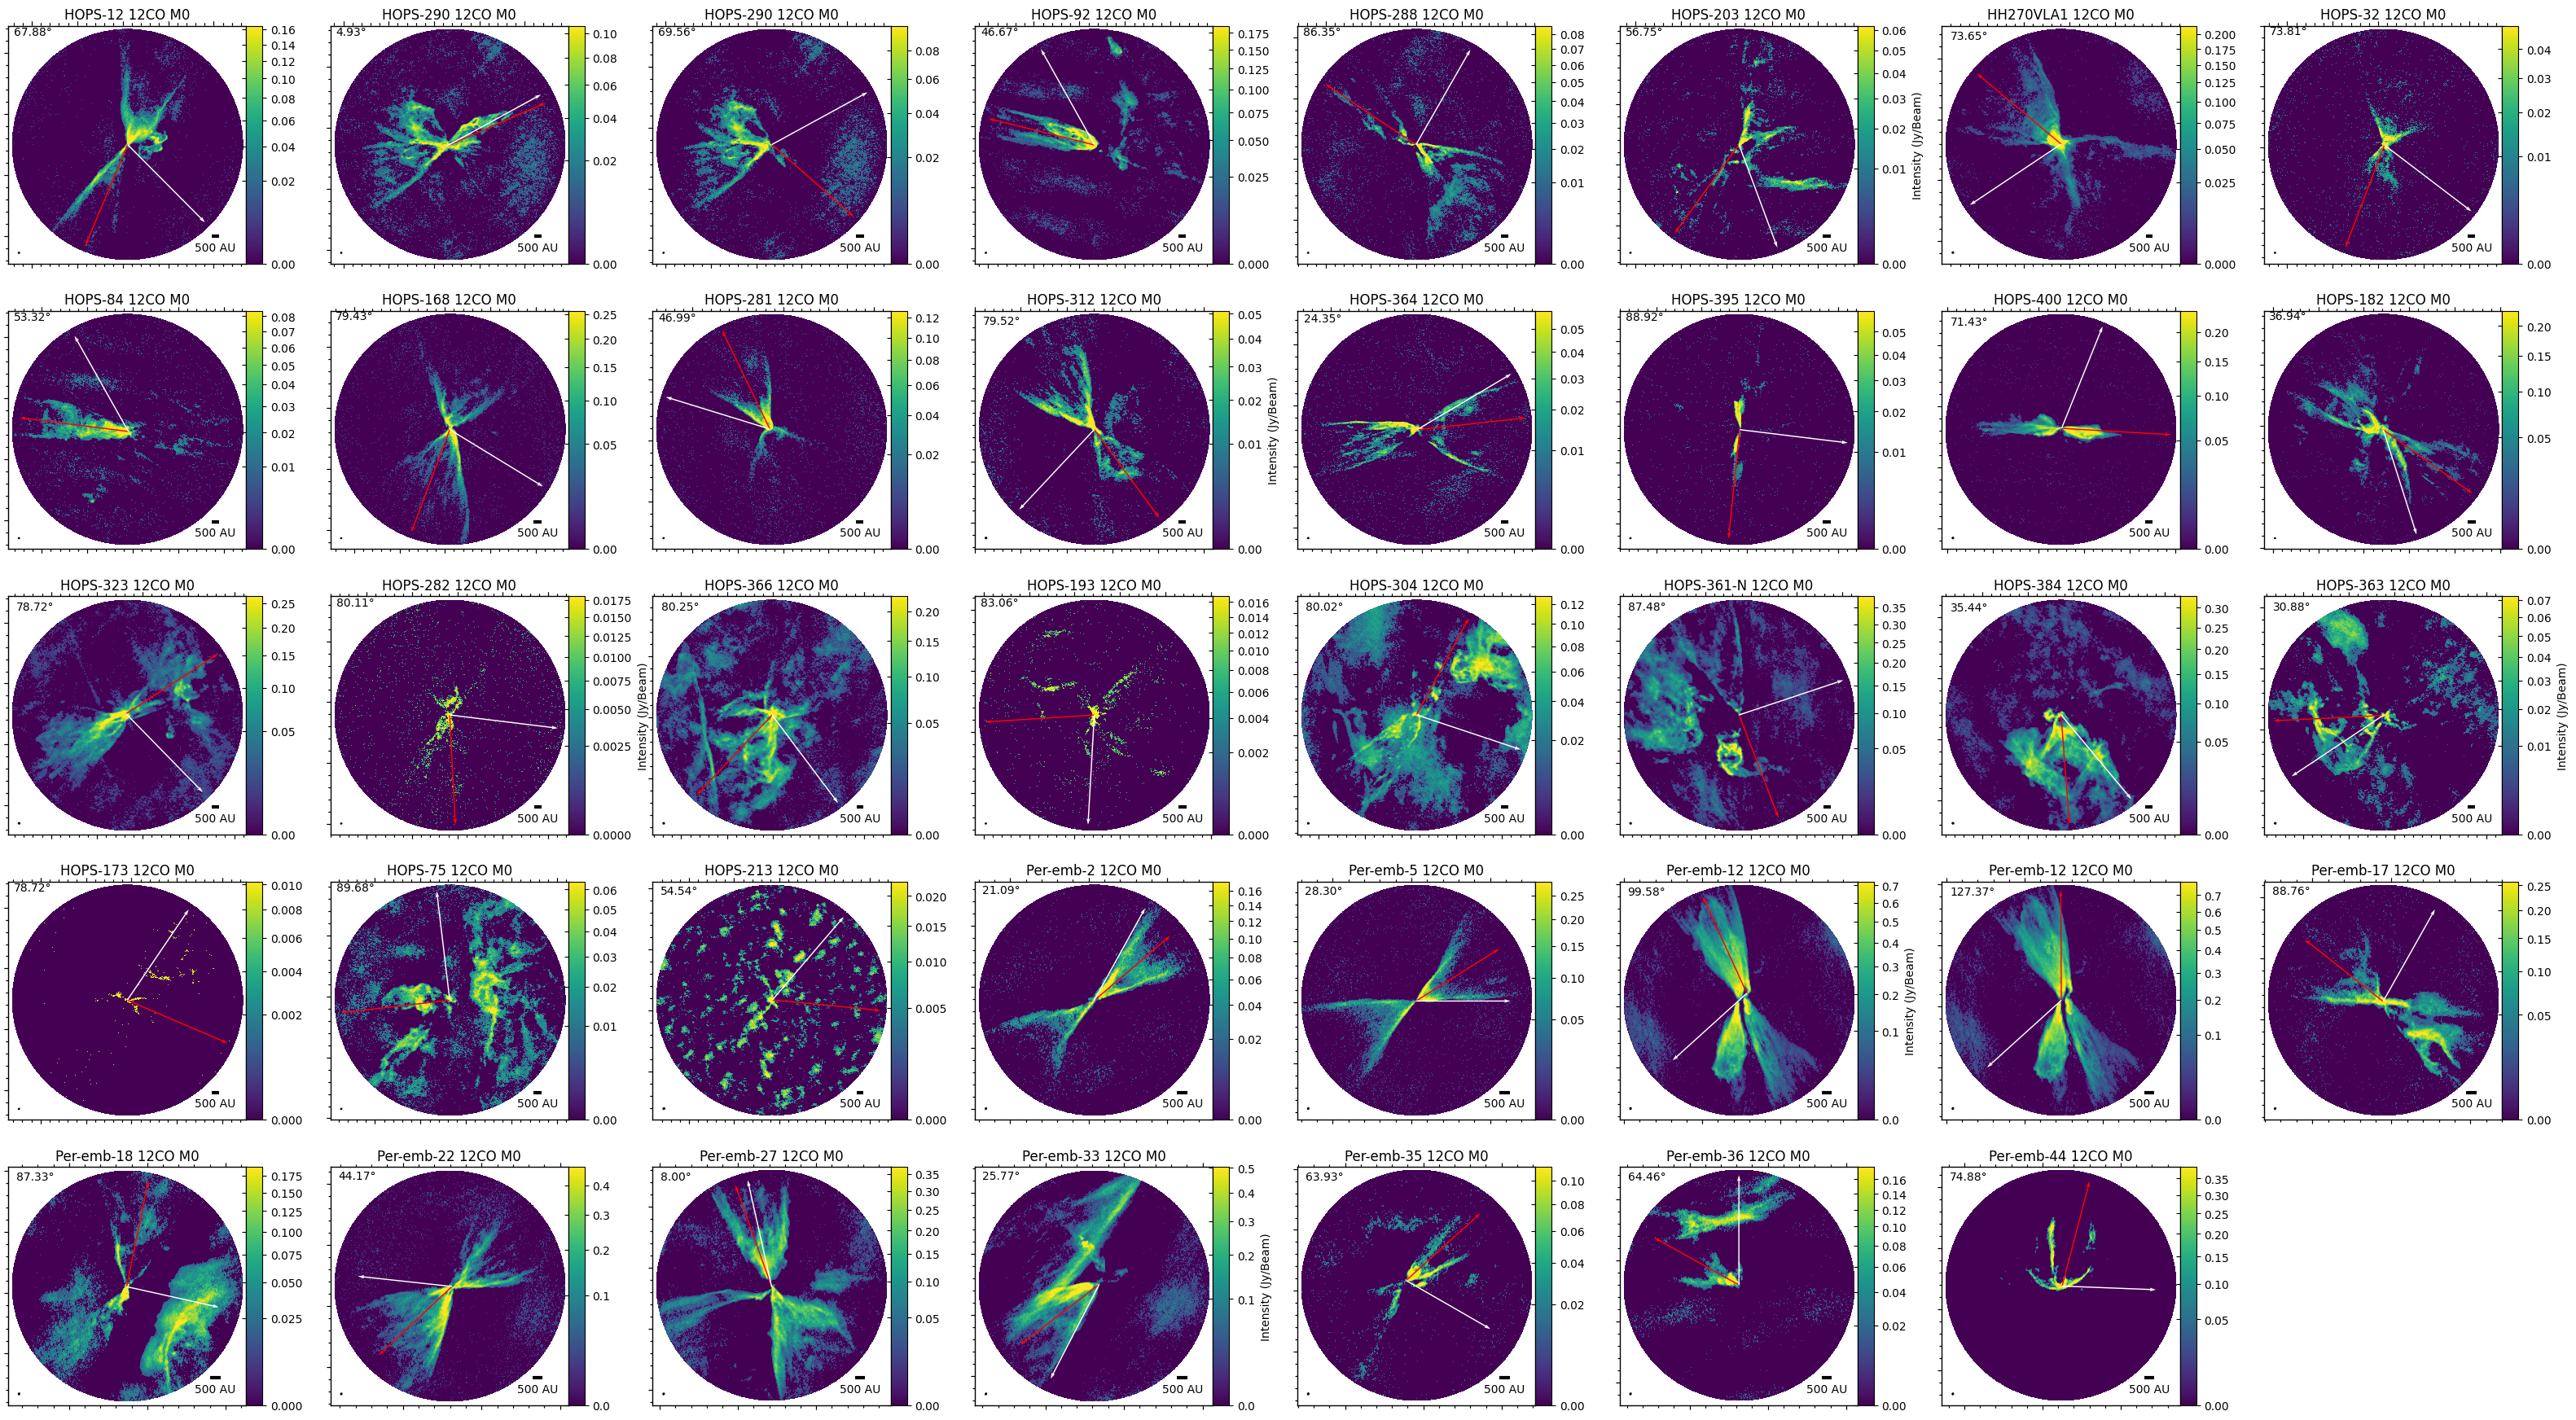

In [17]:
# script options
overwrite = False
output_folder = "../results"

# read data
df = pd.read_csv('../data/output/outflow_data.csv')

# helper function to extract channel indices from the data table
def getIdx(listOf):
    ranges = []
    
    for string in listOf:
        if pd.isna(string):  # Skip NaN values
            continue
        
        for part in string.split(', '):
            if '-' in part:  # Handle ranges
                start, end = map(int, part.split('-'))
                ranges.append(np.r_[start:end + 1])  # Use np.r_
            else:  # Handle single values
                ranges.append(int(part))  # Append as integer
    
    # Ensure `ranges` is not empty before passing to np.r_
    if not ranges:
        return np.r_[:]  # Returns an empty np.r_

    return np.r_[tuple(ranges)]  # Use `tuple(ranges)` to avoid errors


figure = plt.figure(figsize=(40, 22))
output_path = os.path.join(output_folder, "master.pdf")

# This loops through each source field with an angle measurement and creates
# a figure with the separation vector and outflow vector overlayed
for i, field in df.iterrows():

    # verify output path exists and
    # skip already existing files if you don't want to overwrite them
    target_name = field['field']


    # verify output path exists and
    if not os.path.exists(output_folder):
        os.mkdir(output_folder)

    # open image
    image_filename = (glob.glob(f'/Volumes/Alpha/Research/data/{target_name.casefold()}/*12co*.fits') + glob.glob(f'/Volumes/Alpha/Research/data/{target_name.casefold()}/*spw39*.fits'))[0]
    hdulist = fits.open(image_filename)    
    hdu = hdulist[0]

    # set center and size of cutout
    center = SkyCoord(hdu.header['OBSRA'], hdu.header['OBSDEC'], unit=u.degree)
    size = np.array([39, 39]) * u.arcsecond
    distance = field['distance']

    # create figure
    channels = getIdx([field['red_channels'], field['blue_channels']])
    fig = create_m0_map(hdu, center, size, channels, 3, distance, figure, subplot=(5, 8, i+1), multiimage=True)
    fig.set_title(f"{target_name} 12CO M0")

    # add a marker at each source with legend
    # mark_sources_2(fig, field)

    ### VECTORS
    # define vector origin at the outflow source
    if field['outflow_source'] == 'both':
        outflow_origin = np.array([np.mean([field['source_a_ra'], field['source_b_ra']]), np.mean([field['source_a_dec'], field['source_b_dec']])])
    elif field['outflow_source'] == field['source_a']:
        outflow_origin = np.array([field['source_a_ra'], field['source_a_dec']])
    else:
        outflow_origin = np.array([field['source_b_ra'], field['source_b_dec']])

    # plot outflow angle
    outflow_angle_north = field['outflow_PA']
    plot_vector(fig, outflow_origin, outflow_angle_north, color='red', length=0.005)
    
    # plot separation angle
    separation_angle_north = field['binary_PA']
    # choose a separation vector that provides the smallest angle between vectors
    angle = np.abs(outflow_angle_north - separation_angle_north)
    if angle < 90:
        plot_vector(fig, outflow_origin, separation_angle_north, color='white', length=0.005)
    else:
        plot_vector(fig, outflow_origin, separation_angle_north + 180, color='white', length=0.005)
        angle = 180 - angle

    # display angle between outflow and separation in top left corner
    fig.ax.text(30,fig.ax.get_xlim()[1]-50, f"{np.abs(angle):.2f}°")

    # # Only show y-axis label and ticks on rightmost plot
    # if i % 6 != 0:
    #     fig.axis_labels.hide_y()

    # # only show x-axis label on bottom plots
    # if i < 24:
    #     fig.axis_labels.hide_x()

    # only show colorbar label on leftmost plots
    if i % 6 != 5:
        fig.colorbar.set_axis_label_text("")

    fig.axis_labels.hide()
    fig.tick_labels.hide()


plt.subplots_adjust(wspace=0.2, hspace=0.2)

# save image
figure.savefig(output_path)
figure.show()